In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Excel dataset
df = pd.read_excel("Dataset for Data Analytics.xlsx")

# Display first 5 rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID         

In [4]:
# Statistical summary
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [5]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [6]:
# Fill missing CouponCode values with the most frequent value
df["CouponCode"] = df["CouponCode"].fillna(df["CouponCode"].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [7]:
# Numerical columns
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

# Detect outliers using IQR
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


In [8]:
# Handle outliers using IQR capping

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values within the IQR limits
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outliers have been handled using IQR capping.")

Outliers have been handled using IQR capping.


In [9]:
df["OrderYear"] = df["Date"].dt.year

In [10]:
df["OrderMonth"] = df["Date"].dt.month

In [11]:
df["AverageItemValue"] = df["TotalPrice"] / df["Quantity"]

In [12]:
df["CartValue"] = df["ItemsInCart"] * df["UnitPrice"]

In [13]:
df["OrderDayOfWeek"] = df["Date"].dt.dayofweek

In [14]:
# Feature Engineering

# 1. Order year
df["OrderYear"] = df["Date"].dt.year

# 2. Order month
df["OrderMonth"] = df["Date"].dt.month

# 3. Average value per item
df["AverageItemValue"] = df["TotalPrice"] / df["Quantity"]

# 4. Estimated cart value
df["CartValue"] = df["ItemsInCart"] * df["UnitPrice"]

# 5. Day of week
df["OrderDayOfWeek"] = df["Date"].dt.dayofweek

print("New features created successfully!")

df.head()

New features created successfully!


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderYear,OrderMonth,AverageItemValue,CartValue,OrderDayOfWeek
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,570.62,3994.34,2
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,151.35,454.05,4
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,550.68,4405.44,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,273.19,1365.95,6
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,626.01,5008.08,3


In [15]:
print("New Dataset Shape:", df.shape)

print("\nNew Columns:")
print(df.columns.tolist())

New Dataset Shape: (1200, 19)

New Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'OrderYear', 'OrderMonth', 'AverageItemValue', 'CartValue', 'OrderDayOfWeek']


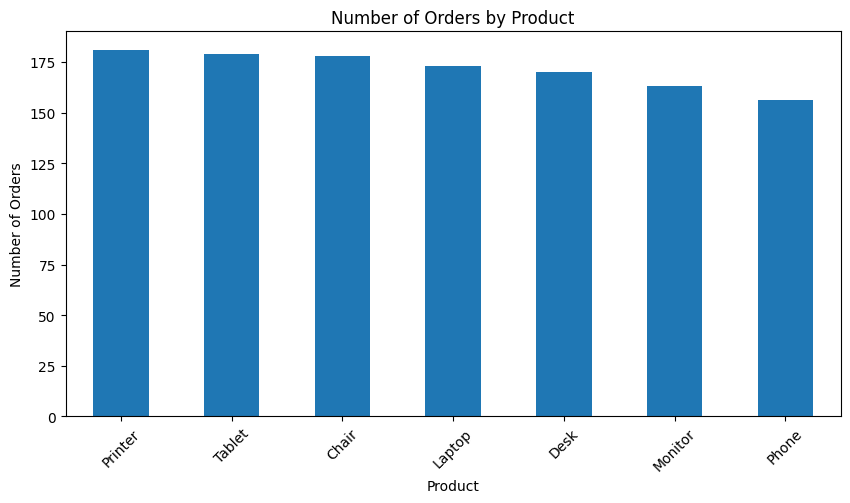

In [16]:
plt.figure(figsize=(10,5))

df["Product"].value_counts().plot(kind="bar")

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

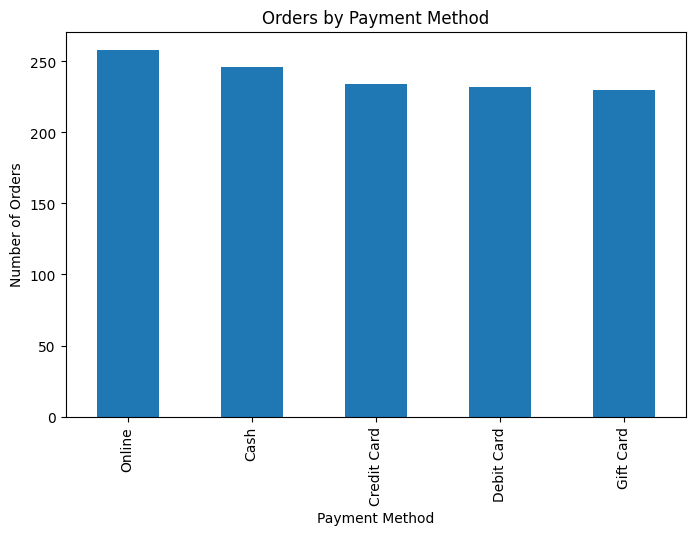

In [17]:
plt.figure(figsize=(8,5))

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

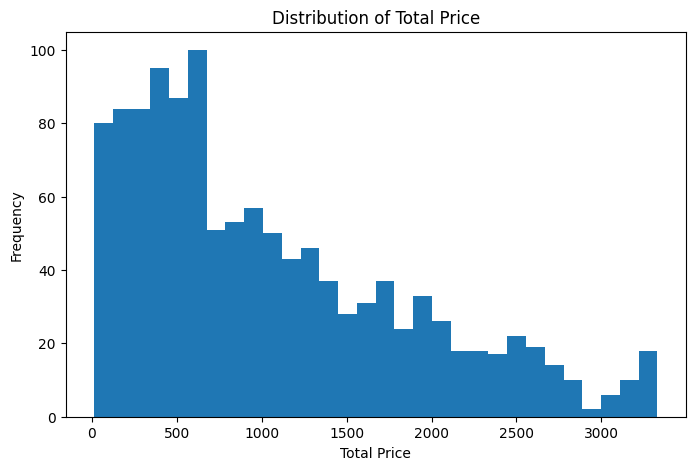

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=30)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

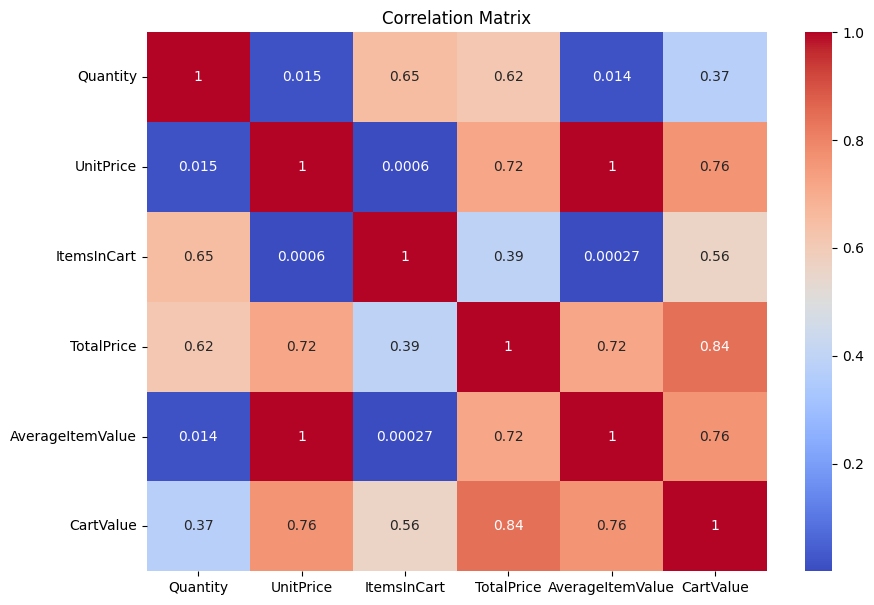

In [19]:
correlation = df[
    ["Quantity", "UnitPrice", "ItemsInCart",
     "TotalPrice", "AverageItemValue", "CartValue"]
].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
print("Final Missing Values:")
print(df.isnull().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset:")
display(df.head())

Final Missing Values:
OrderID             0
Date                0
CustomerID          0
Product             0
Quantity            0
UnitPrice           0
ShippingAddress     0
PaymentMethod       0
OrderStatus         0
TrackingNumber      0
ItemsInCart         0
CouponCode          0
ReferralSource      0
TotalPrice          0
OrderYear           0
OrderMonth          0
AverageItemValue    0
CartValue           0
OrderDayOfWeek      0
dtype: int64

Final Dataset Shape:
(1200, 19)

Final Dataset:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderYear,OrderMonth,AverageItemValue,CartValue,OrderDayOfWeek
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,570.62,3994.34,2
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,151.35,454.05,4
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,550.68,4405.44,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,273.19,1365.95,6
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,626.01,5008.08,3


In [21]:
# Save cleaned dataset
df.to_csv("cleaned_data_science_project_1.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
